# 15: Common Pitfalls, Debugging, and Reporting

This final EconML tutorial is about failure modes. The earlier notebooks showed how to fit estimators, inspect heterogeneity, estimate policies, and build an end-to-end case study. Real applied causal work often fails in quieter ways: weak overlap, leakage, invalid controls, poor nuisance models, overfit CATE stories, or reports that hide key assumptions.

The notebook uses a synthetic observational setting with known truth. That lets us run a clean reference analysis and then deliberately contaminate the workflow in several ways. The goal is to learn what the failure modes look like in tables, figures, and policy outputs.

## Learning Goals

By the end, you should be able to:

- Recognize when treatment overlap is weak enough to make CATE estimates fragile.
- Detect leakage from outcome-like or post-treatment features.
- Understand why bad nuisance models can distort average and heterogeneous effects.
- See why conditioning on post-treatment variables can block part of the effect you want to estimate.
- Avoid over-reading noisy unit-level CATE estimates.
- Build a transparent reporting checklist for EconML analyses.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **Common Pitfalls, Debugging, And Reporting**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The examples are failure cases by design. They are included so readers learn how plausible causal workflows break in practice. The experiment studies latent representation discovery. Indicators are useful only when the measurement structure supports the hidden-factor story.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

Applied EconML workflows connect effect estimation to decisions,

$$
\text{design assumptions} \rightarrow \widehat\tau(X) \rightarrow \pi(X) \rightarrow \widehat V(\pi).
$$

A support-aware policy can be written as

$$
\pi(X)=\mathbf{1}\{\widehat\tau(X)>c(X)\}\mathbf{1}\{\widehat e(X)\in[\epsilon,1-\epsilon]\}.
$$

The full decision chain matters more than a single attractive CATE estimate.



The workflow is diagnostic rather than estimator-first:

1. Build a clean example dataset with known treatment effects.
2. Fit a reference EconML model and save its diagnostics.
3. Stress-test overlap using propensity buckets and trimming logic.
4. Create a leakage example and show why it is invalid even when metrics look appealing.
5. Compare flexible nuisance models with overly simple nuisance models.
6. Show how post-treatment controls can change the estimand.
7. Use calibration, segments, and bootstrap intervals to avoid overconfident CATE stories.
8. End with a reusable debugging and reporting checklist.




## Tutorial Workflow

#### Setup

The first code cell imports the libraries, configures plotting, suppresses known implementation warnings, and creates output folders. The `MPLCONFIGDIR` setting prevents Matplotlib cache warnings during notebook execution.

In [1]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import time
import warnings

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "econml":
    NOTEBOOK_DIR = Path("notebooks/tutorials/econml").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in [FIGURE_DIR, TABLE_DIR, REPORT_DIR, OUTPUT_DIR / "matplotlib_cache"]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str((OUTPUT_DIR / "matplotlib_cache").resolve()))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress.*")
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*column-vector y was passed.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
warnings.filterwarnings("ignore", message=".*lbfgs failed to converge.*")
warnings.filterwarnings("ignore", message=".*invalid value encountered.*")

import numpy as np

# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default

    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.special import expit
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import log_loss, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

from econml.dml import CausalForestDML, LinearDML
from econml.dr import DRLearner

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


IPython could not be loaded!


The environment is ready and all outputs will be written with a `15_` prefix. This keeps the final tutorial outputs separate from earlier notebooks in the same folder.


### Reproducibility Settings

The notebook uses simulation, train-test splits, tree models, and bootstrap resampling. The seed keeps results stable while preserving enough randomness to reveal realistic failure patterns.

In [2]:
RANDOM_STATE = 20260430
rng = np.random.default_rng(RANDOM_STATE)
CASE_PREFIX = "15"
N_USERS = 5_200
TEST_SIZE = 0.30
TREATMENT_COST = 0.16

settings = pd.DataFrame(
    {
        "setting": ["random_state", "n_users", "test_size", "treatment_cost"],
        "value": [RANDOM_STATE, N_USERS, TEST_SIZE, TREATMENT_COST],
        "why_it_matters": [
            "Makes the synthetic examples and bootstrap checks reproducible.",
            "Keeps estimator fitting fast while leaving enough rows for diagnostics.",
            "Creates held-out data for honest model comparison.",
            "Turns treatment effects into net decision value.",
        ],
    }
)
settings.to_csv(TABLE_DIR / f"{CASE_PREFIX}_analysis_settings.csv", index=False)
display(settings)


,setting,value,why_it_matters
0,random_state,"20,260,430.0000",Makes the synthetic examples and bootstrap checks reproducible.
1,n_users,"5,200.0000",Keeps estimator fitting fast while leaving enough rows for diagnostics.
2,test_size,0.3000,Creates held-out data for honest model comparison.
3,treatment_cost,0.1600,Turns treatment effects into net decision value.


The cost value will be used later to show why good CATE estimates are not enough. A policy must create net value after costs, produce net value, more than positive estimated effects.




## Reporting and Takeaways

### Pitfall Map

Before touching data, we write down the specific risks this lesson will demonstrate. This habit helps separate causal design problems from software or modeling problems.

| risk | what_goes_wrong | how_to_debug |
| --- | --- | --- |
| Weak overlap | Some users have almost no chance of being treated or untreated. | Propensity distributions, bucket counts, effective sample size, trimming checks. |
| Outcome leakage | A feature contains future outcome information or is built after the outcome window. | Too-good metrics, suspicious feature timing, impossible prediction inputs. |
| Post-treatment controls | A mediator or downstream variable is used as a confounder. | Estimated effect changes because part of the treatment pathway is blocked. |
| Bad nuisance models | Treatment or outcome models are too weak for the adjustment problem. | Poor nuisance diagnostics, unstable CATE estimates, weak calibration. |
| Overread unit CATE | Individual treatment effects are treated as precise facts. | Noisy scatter, unstable deciles, wide bootstrap policy intervals. |
| Segment hunting | Many segments are searched until some look impressive by chance. | Random segment stress tests and transparent multiple-comparison caveats. |
| Thin reporting | A report gives a point estimate without assumptions, diagnostics, or caveats. | Checklist requiring estimand, overlap, model diagnostics, sensitivity, and decision context. |


The rest of the notebook turns these rows into concrete examples. The point is not that EconML is fragile; the point is that causal estimation is only as credible as the design and diagnostics around it.



### Synthetic Data-Generating Process

The helper functions define a clean target causal problem. We create pre-treatment user features, a treatment assignment mechanism, a baseline outcome, and a true heterogeneous treatment effect.

The simulation also creates two dangerous columns: a post-treatment activity variable and a leaky outcome proxy. They are intentionally included so we can demonstrate why they should not be used as normal pre-treatment features.

In [3]:
# Define reusable helpers for the Synthetic Data-Generating Process section.
def make_correlated_normals(n_rows, n_features, correlation, rng):
    """
    Idea: Construct the correlated normals used in the Synthetic Data-Generating Process section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n_rows : object
        Number of rows to generate, display, or sample.
    n_features : object
        Number of simulated or selected features in the design matrix.
    correlation : object
        Correlation value used to decide whether an exploratory edge is plausible.
    rng : np.random.Generator
        Random generator that makes the simulation reproducible.
    
    Returns
    -------
    np.ndarray
        Matrix of correlated normal covariates used by the semi-synthetic EconML design.
    """
    covariance = np.full((n_features, n_features), correlation)
    np.fill_diagonal(covariance, 1.0)
    return rng.multivariate_normal(np.zeros(n_features), covariance, size=n_rows)


def true_cate_function(frame):
    """
    Idea: Evaluate the true CATE function used by the simulator or nuisance-model diagnostic.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    
    Returns
    -------
    pd.Series or np.ndarray
        Oracle row-level CATE values generated from the synthetic treatment-effect function.
    """
    return (
        0.24
        + 0.30 * frame["need_score"]
        + 0.22 * frame["preference_match"]
        + 0.16 * np.maximum(frame["search_friction"], 0)
        - 0.20 * frame["price_sensitivity"]
        + 0.14 * frame["high_intent_segment"]
        + 0.08 * frame["device_quality"] * frame["preference_match"]
        - 0.10 * frame["competitive_pressure"]
    )


def treatment_propensity_function(frame, severe=False):
    """
    Idea: Evaluate the treatment propensity function used by the simulator or nuisance-model diagnostic.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    severe : object
        Whether the simulated failure mode should be made more extreme.
    
    Returns
    -------
    np.ndarray
        Propensity-score vector clipped to the design support bounds.
    """
    multiplier = 1.8 if severe else 1.0
    logit = multiplier * (
        -0.15
        + 0.62 * frame["need_score"]
        + 0.50 * frame["prior_activity"]
        + 0.40 * frame["high_intent_segment"]
        + 0.35 * frame["marketing_intensity"]
        - 0.30 * frame["device_quality"]
        + 0.20 * frame["search_friction"]
    )
    lower, upper = (0.01, 0.99) if severe else (0.05, 0.95)
    return np.clip(expit(logit), lower, upper)


def baseline_outcome_function(frame):
    """
    Idea: Evaluate the baseline outcome function used by the simulator or nuisance-model diagnostic.
    
    Parameters
    ----------
    frame : pd.DataFrame
        Table-like object being transformed.
    
    Returns
    -------
    pd.Series or np.ndarray
        Oracle baseline outcome values under no treatment for each synthetic observation.
    """
    return (
        1.20
        + 0.48 * frame["prior_activity"]
        + 0.36 * frame["preference_match"]
        - 0.34 * frame["search_friction"]
        - 0.22 * frame["price_sensitivity"]
        + 0.24 * frame["device_quality"]
        + 0.16 * frame["market_maturity"]
        + 0.12 * frame["organic_source"]
        + 0.06 * np.sin(frame["tenure_weeks"] / 4.0)
    )


The true CATE is deliberately nonlinear. That makes the clean analysis nontrivial and gives us a useful benchmark when we later compare bad design choices.

### Generate the Example Dataset

The code below creates an observational user table. Treatment is targeted, the outcome is noisy, and a few fields have light missingness. The dangerous fields are clearly named so their timing problems are visible.

In [4]:
# Save the artifacts produced by the Generate The Example Dataset section.
latent = make_correlated_normals(N_USERS, 6, correlation=0.25, rng=rng)
data = pd.DataFrame(
    {
        "user_id": np.arange(1, N_USERS + 1),
        "need_score": latent[:, 0],
        "prior_activity": latent[:, 1],
        "preference_match": latent[:, 2],
        "search_friction": latent[:, 3],
        "price_sensitivity": latent[:, 4],
        "device_quality": latent[:, 5],
    }
)

data["marketing_intensity"] = rng.normal(0, 1, N_USERS)
data["competitive_pressure"] = rng.normal(0, 1, N_USERS)
data["market_maturity"] = rng.normal(0, 1, N_USERS)
data["tenure_weeks"] = np.clip(rng.gamma(shape=3.0, scale=4.0, size=N_USERS), 1, 48)
data["organic_source"] = rng.binomial(1, expit(0.10 + 0.30 * data["preference_match"]), N_USERS)
data["weekday_signup"] = rng.binomial(1, 0.70, N_USERS)
data["high_intent_segment"] = rng.binomial(
    1,
    expit(0.35 * data["prior_activity"] + 0.30 * data["preference_match"] - 0.12 * data["price_sensitivity"]),
    N_USERS,
)

data["true_cate"] = true_cate_function(data)
data["true_propensity"] = treatment_propensity_function(data, severe=False)
data["treatment"] = rng.binomial(1, data["true_propensity"], N_USERS)
data["baseline_outcome"] = baseline_outcome_function(data)
data["outcome"] = data["baseline_outcome"] + data["treatment"] * data["true_cate"] + rng.normal(0, 0.70, N_USERS)

# These two columns are intentionally dangerous. They are not valid pre-treatment controls.
data["post_treatment_activity"] = 0.65 * data["treatment"] + 0.40 * data["true_cate"] + 0.35 * data["prior_activity"] + rng.normal(0, 0.55, N_USERS)
data["leaky_outcome_proxy"] = data["outcome"] + rng.normal(0, 0.20, N_USERS)

for column, missing_rate in {"preference_match": 0.025, "search_friction": 0.030, "device_quality": 0.020}.items():
    data.loc[rng.random(N_USERS) < missing_rate, column] = np.nan

data.to_csv(TABLE_DIR / f"{CASE_PREFIX}_pitfall_teaching_data.csv", index=False)
display(data.head())


,user_id,need_score,prior_activity,preference_match,search_friction,price_sensitivity,device_quality,marketing_intensity,competitive_pressure,market_maturity,tenure_weeks,organic_source,weekday_signup,high_intent_segment,true_cate,true_propensity,treatment,baseline_outcome,outcome,post_treatment_activity,leaky_outcome_proxy
0,1,0.7059,0.0571,-0.5594,0.8454,0.1722,1.0620,0.8506,0.0623,-1.1204,11.2538,1,1,0,0.3758,0.6141,1,0.9157,0.2184,0.6957,0.0188
1,2,-0.0540,-0.2884,0.9522,0.2782,-1.7934,0.2560,-2.0918,0.5260,1.8166,9.3135,1,0,1,0.9434,0.3360,0,2.2200,2.4476,0.9286,2.3796
2,3,1.8433,0.4595,0.9130,1.0479,0.3843,0.2413,-0.6062,-1.2137,1.0250,24.2055,1,1,1,1.3636,0.8246,0,1.6365,1.3172,1.5100,1.2147
3,4,0.0350,0.1052,1.4770,0.3775,-1.7736,1.2076,0.0720,-1.5952,-1.3030,8.5236,1,0,1,1.4328,0.5157,0,2.2962,3.0734,-0.2245,3.1225
4,5,0.2625,1.3947,0.1096,-0.5099,-1.4671,-1.2981,1.2255,-1.7827,-0.4524,12.2572,0,1,1,0.9432,0.8613,1,2.0258,1.8911,1.3667,1.8260


The dataset includes the clean ingredients plus two traps. `post_treatment_activity` happens after treatment and may mediate the treatment effect. `leaky_outcome_proxy` is essentially future outcome information. Both would make a real CATE analysis invalid if used as normal covariates.



### Field Dictionary and Timing Audit

A timing audit is one of the best leakage defenses. Every feature should be labeled as pre-treatment, treatment, outcome, post-treatment, or hidden teaching truth.

In [5]:
# Save the artifacts produced by the Field Dictionary And Timing Audit section.
field_dictionary = pd.DataFrame(
    [
        ("user_id", "Identifier", "Row identifier.", "Identifier", "Do not model."),
        ("need_score", "Numeric", "Pre-treatment signal of onboarding need.", "Pre-treatment", "Allowed X."),
        ("prior_activity", "Numeric", "Pre-treatment usage activity.", "Pre-treatment", "Allowed X."),
        ("preference_match", "Numeric", "Pre-treatment match between user interests and catalog.", "Pre-treatment", "Allowed X."),
        ("search_friction", "Numeric", "Pre-treatment difficulty finding relevant content.", "Pre-treatment", "Allowed X."),
        ("price_sensitivity", "Numeric", "Pre-treatment cost sensitivity proxy.", "Pre-treatment", "Allowed X."),
        ("device_quality", "Numeric", "Pre-treatment device or experience quality proxy.", "Pre-treatment", "Allowed X."),
        ("high_intent_segment", "Binary", "Pre-treatment segment flag.", "Pre-treatment", "Allowed X."),
        ("marketing_intensity", "Numeric", "Other pre-treatment marketing pressure.", "Pre-treatment", "Allowed W."),
        ("competitive_pressure", "Numeric", "Pre-treatment market competition proxy.", "Pre-treatment", "Allowed W."),
        ("market_maturity", "Numeric", "Market maturity proxy.", "Pre-treatment", "Allowed W."),
        ("tenure_weeks", "Numeric", "Account age before treatment.", "Pre-treatment", "Allowed W."),
        ("organic_source", "Binary", "Acquisition source before treatment.", "Pre-treatment", "Allowed W."),
        ("weekday_signup", "Binary", "Signup timing before treatment.", "Pre-treatment", "Allowed W."),
        ("treatment", "Binary", "Whether the user received the intervention.", "Treatment", "T."),
        ("outcome", "Numeric", "Post-treatment outcome.", "Outcome", "Y."),
        ("post_treatment_activity", "Numeric", "Activity after treatment starts.", "Post-treatment", "Pitfall: do not adjust as a confounder."),
        ("leaky_outcome_proxy", "Numeric", "Noisy copy of the outcome.", "Outcome-like leakage", "Pitfall: do not use as a feature."),
        ("true_cate", "Numeric", "Known individual effect in simulation.", "Hidden truth", "Evaluation only."),
        ("true_propensity", "Numeric", "Known assignment probability in simulation.", "Hidden truth", "Evaluation only."),
        ("baseline_outcome", "Numeric", "Known untreated outcome component.", "Hidden truth", "Evaluation only."),
    ],
    columns=["field", "type", "description", "timing", "modeling_status"],
)
field_dictionary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_field_dictionary_timing_audit.csv", index=False)
display(field_dictionary)


,field,type,description,timing,modeling_status
0,user_id,Identifier,Row identifier.,Identifier,Do not model.
1,need_score,Numeric,Pre-treatment signal of onboarding need.,Pre-treatment,Allowed X.
2,prior_activity,Numeric,Pre-treatment usage activity.,Pre-treatment,Allowed X.
3,preference_match,Numeric,Pre-treatment match between user interests and catalog.,Pre-treatment,Allowed X.
4,search_friction,Numeric,Pre-treatment difficulty finding relevant content.,Pre-treatment,Allowed X.
5,price_sensitivity,Numeric,Pre-treatment cost sensitivity proxy.,Pre-treatment,Allowed X.
6,device_quality,Numeric,Pre-treatment device or experience quality proxy.,Pre-treatment,Allowed X.
7,high_intent_segment,Binary,Pre-treatment segment flag.,Pre-treatment,Allowed X.
8,marketing_intensity,Numeric,Other pre-treatment marketing pressure.,Pre-treatment,Allowed W.
9,competitive_pressure,Numeric,Pre-treatment market competition proxy.,Pre-treatment,Allowed W.


The timing audit is a simple but powerful debugging tool. Many impressive-looking causal models fail because a feature quietly includes information that would not exist at decision time.



### Basic Data Quality Checks

Before fitting estimators, we confirm sample size, treatment share, outcome completeness, and missingness patterns.

In [6]:
basic_summary = pd.DataFrame(
    {
        "metric": ["rows", "columns", "treatment_rate", "outcome_missing", "treatment_missing", "true_ate"],
        "value": [
            len(data),
            data.shape[1],
            data["treatment"].mean(),
            data["outcome"].isna().sum(),
            data["treatment"].isna().sum(),
            data["true_cate"].mean(),
        ],
    }
)
missing_summary = (
    data.isna().mean().rename("missing_rate").reset_index().rename(columns={"index": "field"})
    .query("missing_rate > 0")
    .sort_values("missing_rate", ascending=False)
)
basic_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_basic_summary.csv", index=False)
missing_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_missing_summary.csv", index=False)
display(basic_summary)
display(missing_summary)


,metric,value
0,rows,"5,200.0000"
1,columns,21.0000
2,treatment_rate,0.5148
3,outcome_missing,0.0000
4,treatment_missing,0.0000
5,true_ate,0.3825


,field,missing_rate
4,search_friction,0.0290
3,preference_match,0.0242
6,device_quality,0.0221


The core treatment and outcome fields are complete. Light missingness appears only in pre-treatment features, which can be handled with train-only imputation.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


#### Raw Outcome Gap

A raw treated-control comparison serves a different role than a causal estimate here. It is still useful as a baseline. If it differs sharply from the true ATE, that is evidence that confounding matters.

In [7]:
raw_group_summary = (
    data.groupby("treatment")
    .agg(
        users=("user_id", "size"),
        mean_outcome=("outcome", "mean"),
        mean_true_cate=("true_cate", "mean"),
        mean_true_propensity=("true_propensity", "mean"),
    )
    .reset_index()
)
raw_gap = raw_group_summary.loc[raw_group_summary["treatment"] == 1, "mean_outcome"].iloc[0] - raw_group_summary.loc[raw_group_summary["treatment"] == 0, "mean_outcome"].iloc[0]
raw_gap_table = pd.DataFrame(
    {
        "quantity": ["raw_treated_minus_control", "true_ate", "raw_minus_true_ate"],
        "value": [raw_gap, data["true_cate"].mean(), raw_gap - data["true_cate"].mean()],
    }
)
raw_group_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_raw_group_summary.csv", index=False)
raw_gap_table.to_csv(TABLE_DIR / f"{CASE_PREFIX}_raw_gap_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_gap_table)


,treatment,users,mean_outcome,mean_true_cate,mean_true_propensity
0,0,2523,1.1829,0.2605,0.4183
1,1,2677,1.8945,0.4974,0.6004


,quantity,value
0,raw_treated_minus_control,0.7116
1,true_ate,0.3825
2,raw_minus_true_ate,0.3292


The raw difference mixes selection and treatment impact. The treated group has a different average treatment propensity, so adjustment is necessary before making causal claims.



#### True CATE Distribution

The hidden true CATE distribution gives us the benchmark for later model checks. In real work, this distribution would be unknown.

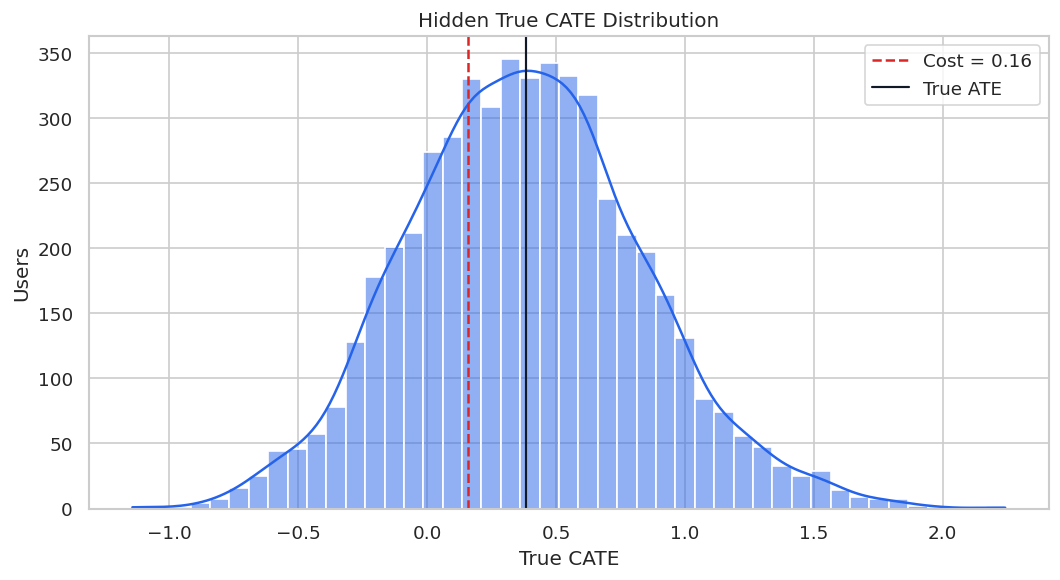

,true_cate
count,"5,200.0000"
mean,0.3825
std,0.4564
min,-1.1440
5%,-0.3367
25%,0.0684
50%,0.3722
75%,0.6712
95%,1.1626
max,2.2424


In [8]:
true_cate_summary = data["true_cate"].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).to_frame("true_cate")
true_cate_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_true_cate_summary.csv")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data["true_cate"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(TREATMENT_COST, color="#dc2626", linestyle="--", linewidth=1.5, label=f"Cost = {TREATMENT_COST:.2f}")
ax.axvline(data["true_cate"].mean(), color="#111827", linewidth=1.3, label="True ATE")
ax.set_title("Hidden True CATE Distribution")
ax.set_xlabel("True CATE")
ax.set_ylabel("Users")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

display(true_cate_summary)


The spread in true CATE creates a legitimate targeting problem. The risk is that bad workflows can create a convincing but wrong story about that heterogeneity.



#### Define Clean Feature Roles

This is the clean design we want to protect. `X` contains pre-treatment effect modifiers, while `W` contains additional pre-treatment controls. Dangerous post-treatment and outcome-like fields are excluded.

In [9]:
# Save the artifacts produced by the Define Clean Feature Roles section.
CLEAN_X_COLUMNS = [
    "need_score",
    "prior_activity",
    "preference_match",
    "search_friction",
    "price_sensitivity",
    "device_quality",
    "high_intent_segment",
]
CLEAN_W_COLUMNS = [
    "marketing_intensity",
    "competitive_pressure",
    "market_maturity",
    "tenure_weeks",
    "organic_source",
    "weekday_signup",
]

feature_role_table = pd.DataFrame(
    {
        "field": CLEAN_X_COLUMNS + CLEAN_W_COLUMNS,
        "role": ["X"] * len(CLEAN_X_COLUMNS) + ["W"] * len(CLEAN_W_COLUMNS),
        "timing": "Pre-treatment",
    }
)
feature_role_table.to_csv(TABLE_DIR / f"{CASE_PREFIX}_clean_feature_roles.csv", index=False)
display(feature_role_table)


,field,role,timing
0,need_score,X,Pre-treatment
1,prior_activity,X,Pre-treatment
2,preference_match,X,Pre-treatment
3,search_friction,X,Pre-treatment
4,price_sensitivity,X,Pre-treatment
5,device_quality,X,Pre-treatment
6,high_intent_segment,X,Pre-treatment
7,marketing_intensity,W,Pre-treatment
8,competitive_pressure,W,Pre-treatment
9,market_maturity,W,Pre-treatment


The clean roles intentionally keep the CATE surface focused and exclude future information. Later pitfall examples will violate this design to show what can go wrong.

#### Train-Test Split

We split once and reuse the same rows across the clean analysis and pitfall examples. This makes comparisons easier to interpret.

In [10]:
train_df, test_df = train_test_split(
    data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=data["treatment"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "treatment_rate": [train_df["treatment"].mean(), test_df["treatment"].mean()],
        "mean_outcome": [train_df["outcome"].mean(), test_df["outcome"].mean()],
        "mean_true_cate": [train_df["true_cate"].mean(), test_df["true_cate"].mean()],
    }
)
split_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_train_test_split_summary.csv", index=False)
display(split_summary)


,split,rows,treatment_rate,mean_outcome,mean_true_cate
0,train,3640,0.5148,1.5562,0.3868
1,test,1560,0.5147,1.5332,0.3723


The train and test samples have similar treatment rates and average true effects. Reusing this split keeps the rest of the notebook apples-to-apples.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Matrix Builder

This helper prepares `X`, `W`, `T`, and `Y` matrices. It learns medians from the training data and can optionally add missingness flags to `W`.

In [11]:
# Define reusable helpers for the Matrix Builder section.
def build_design(train_frame, test_frame, x_columns, w_columns, add_missing_flags=True):
    """
    Idea: Build the design representation used by the Matrix Builder analysis.
    
    Parameters
    ----------
    train_frame : object
        Training rows used to fit the learner.
    test_frame : object
        Held-out rows used to evaluate the learner.
    x_columns : object
        Covariate columns used as model inputs.
    w_columns : object
        Adjustment or control columns used by the estimator.
    add_missing_flags : object
        Context-specific input used for add missing flags in this helper.
    
    Returns
    -------
    tuple
        Train/test design matrices and treatment/outcome arrays in the order used by the estimator.
    """
    model_columns = list(dict.fromkeys(x_columns + w_columns))
    train_medians = train_frame[model_columns].median(numeric_only=True)
    missing_columns = [column for column in model_columns if train_frame[column].isna().any() or test_frame[column].isna().any()]

    def transform(frame):
        """
        Idea: Compute the transform needed in the Matrix Builder section and return it in a form the next cells can inspect.
        
        Parameters
        ----------
        frame : pd.DataFrame
            Table-like object being transformed.
        
        Returns
        -------
        tuple
            Tuple containing X, W, aligned for the causal estimator.
        """
        raw = frame[model_columns].copy()
        filled = raw.fillna(train_medians)
        X = filled[x_columns].astype(float)
        W = filled[w_columns].astype(float)
        if add_missing_flags and missing_columns:
            flags = raw[missing_columns].isna().astype(float).add_suffix("_missing")
            W = pd.concat([W, flags], axis=1)
        return X, W

    X_train, W_train = transform(train_frame)
    X_test, W_test = transform(test_frame)
    T_train = train_frame["treatment"].astype(int)
    T_test = test_frame["treatment"].astype(int)
    Y_train = train_frame["outcome"].astype(float)
    Y_test = test_frame["outcome"].astype(float)
    return X_train, W_train, T_train, Y_train, X_test, W_test, T_test, Y_test

X_train, W_train, T_train, Y_train, X_test, W_test, T_test, Y_test = build_design(
    train_df,
    test_df,
    CLEAN_X_COLUMNS,
    CLEAN_W_COLUMNS,
)
true_tau_test = test_df["true_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    {
        "matrix": ["X_train", "W_train", "X_test", "W_test"],
        "rows": [X_train.shape[0], W_train.shape[0], X_test.shape[0], W_test.shape[0]],
        "columns": [X_train.shape[1], W_train.shape[1], X_test.shape[1], W_test.shape[1]],
        "missing_after_preparation": [
            int(X_train.isna().sum().sum()),
            int(W_train.isna().sum().sum()),
            int(X_test.isna().sum().sum()),
            int(W_test.isna().sum().sum()),
        ],
    }
)
matrix_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_clean_matrix_summary.csv", index=False)
display(matrix_summary)


,matrix,rows,columns,missing_after_preparation
0,X_train,3640,7,0
1,W_train,3640,9,0
2,X_test,1560,7,0
3,W_test,1560,9,0


The prepared matrices are complete and use only pre-treatment fields. This is the reference design against which the failure modes will be compared.

The table is useful because it compresses the evidence into a form that can be compared, audited, and tied back to the causal question.
<!-- result-implication-expanded -->


#### Reusable Model Helpers

These helper functions keep estimator setup consistent across examples. They also make the later comparison tables easier to read.

In [12]:
# Define reusable helpers for the Reusable Model Helpers section.
def make_rf_classifier(seed_offset=0, min_leaf=30):
    """
    Idea: Construct the random-forest classifier used in the Reusable Model Helpers section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    seed_offset : object
        Offset added to the base random seed for a reproducible scenario variant.
    min_leaf : object
        Minimum leaf size controlling the smoothness of the tree or forest learner.
    
    Returns
    -------
    RandomForestClassifier
        Configured random-forest classifier used as a nuisance propensity or treatment model.
    """
    return RandomForestClassifier(
        n_estimators=160,
        min_samples_leaf=min_leaf,
        max_features=0.75,
        random_state=RANDOM_STATE + seed_offset,
        n_jobs=-1,
    )


def make_rf_regressor(seed_offset=0, min_leaf=25):
    """
    Idea: Construct the random-forest regressor used in the Reusable Model Helpers section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    seed_offset : object
        Offset added to the base random seed for a reproducible scenario variant.
    min_leaf : object
        Minimum leaf size controlling the smoothness of the tree or forest learner.
    
    Returns
    -------
    RandomForestRegressor
        Configured random-forest regressor used as an outcome or final-stage model.
    """
    return RandomForestRegressor(
        n_estimators=160,
        min_samples_leaf=min_leaf,
        max_features=0.75,
        random_state=RANDOM_STATE + seed_offset,
        n_jobs=-1,
    )


def safe_corr(left, right):
    """
    Idea: Compute a correlation only when both inputs contain enough variation to make the result meaningful.
    
    Parameters
    ----------
    left : object
        Left-side value, node, or coordinate in a comparison.
    right : object
        Right-side value, node, or coordinate in a comparison.
    
    Returns
    -------
    float
        Pearson correlation, or NaN when either input has too little variation.
    """
    if np.std(left) == 0 or np.std(right) == 0:
        return np.nan
    return float(np.corrcoef(left, right)[0, 1])


def summarize_effects(label, estimated, true_tau, fit_seconds, notes):
    """
    Idea: Summarize the effects into a compact table for interpretation in the Reusable Model Helpers section.
    
    Parameters
    ----------
    label : str
        Short label attached to a scenario, method, or plotted result.
    estimated : object
        Context-specific input used for estimated in this helper.
    true_tau : object
        Context-specific input used for true tau in this helper.
    fit_seconds : object
        Context-specific input used for fit seconds in this helper.
    notes : object
        Context-specific input used for notes in this helper.
    
    Returns
    -------
    dict[str, float]
        Effect-estimator summary with ATE bias, CATE errors, ranking quality, policy value, runtime, and notes.
    """
    estimated = np.asarray(estimated)
    top_mask = estimated >= np.quantile(estimated, 0.80)
    action = estimated > TREATMENT_COST
    return {
        "analysis": label,
        "estimated_ate": estimated.mean(),
        "true_ate_test": true_tau.mean(),
        "ate_bias": estimated.mean() - true_tau.mean(),
        "cate_rmse": mean_squared_error(true_tau, estimated) ** 0.5,
        "cate_mae": mean_absolute_error(true_tau, estimated),
        "cate_correlation": safe_corr(true_tau, estimated),
        "top_20_true_cate_mean": true_tau[top_mask].mean(),
        "share_estimated_above_cost": action.mean(),
        "true_net_policy_value": ((true_tau - TREATMENT_COST) * action).mean(),
        "fit_seconds": fit_seconds,
        "notes": notes,
    }


The summary function includes both estimation metrics and policy metrics. This is deliberate: a model can look acceptable statistically while still creating a weak decision rule.

#### Clean Reference Estimators

We begin with a reasonably careful reference analysis using only valid pre-treatment features. Two estimators are fit: a flexible causal forest and a doubly robust learner.

In [13]:
# Fit or evaluate the model objects used in the Clean Reference Estimators section.
reference_estimators = {
    "Clean CausalForestDML": CausalForestDML(
        model_y=make_rf_regressor(101),
        model_t=make_rf_classifier(102),
        discrete_treatment=True,
        n_estimators=160,
        min_samples_leaf=18,
        max_samples=0.45,
        cv=3,
        random_state=RANDOM_STATE,
    ),
    "Clean DRLearner": DRLearner(
        model_propensity=make_rf_classifier(201),
        model_regression=make_rf_regressor(202),
        model_final=make_rf_regressor(203),
        min_propensity=0.02,
        cv=3,
        random_state=RANDOM_STATE,
    ),
}

reference_effects = {}
reference_rows = []
for label, estimator in reference_estimators.items():
    start = time.perf_counter()
    estimator.fit(Y_train, T_train, X=X_train, W=W_train)
    fit_seconds = time.perf_counter() - start
    estimated = estimator.effect(X_test)
    reference_effects[label] = estimated
    reference_rows.append(summarize_effects(label, estimated, true_tau_test, fit_seconds, "Clean pre-treatment design."))

reference_metrics = pd.DataFrame(reference_rows).sort_values("cate_rmse")
reference_metrics.to_csv(TABLE_DIR / f"{CASE_PREFIX}_reference_estimator_metrics.csv", index=False)
display(reference_metrics)


,analysis,estimated_ate,true_ate_test,ate_bias,cate_rmse,cate_mae,cate_correlation,top_20_true_cate_mean,share_estimated_above_cost,true_net_policy_value,fit_seconds,notes
1,Clean DRLearner,0.3458,0.3723,-0.0266,0.2532,0.1999,0.8484,0.9207,0.6365,0.2813,3.3500,Clean pre-treatment design.
0,Clean CausalForestDML,0.3609,0.3723,-0.0115,0.2667,0.2074,0.8733,0.9467,0.7494,0.2815,3.1151,Clean pre-treatment design.


The reference estimates are limited as perfect. They give us a defensible baseline. Later tables will compare questionable workflows to these clean estimates.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




#### Reference CATE Recovery Plot

The scatterplot compares the best clean reference estimator with the known true CATE. This visual is a useful reminder that individual CATEs are noisy even in a clean simulation.

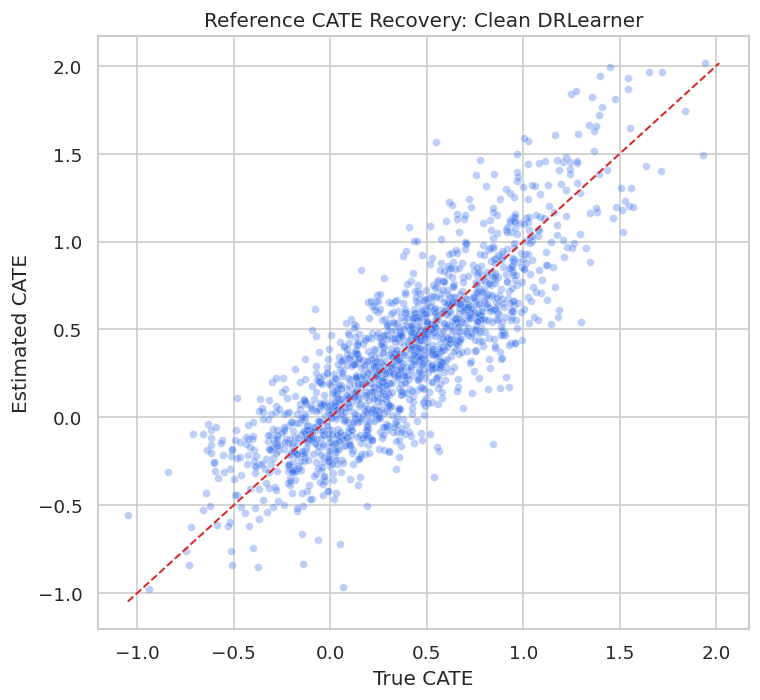

In [14]:
best_reference_label = reference_metrics.iloc[0]["analysis"]
best_reference_effect = reference_effects[best_reference_label]

fig, ax = plt.subplots(figsize=(6.5, 6))
sns.scatterplot(x=true_tau_test, y=best_reference_effect, alpha=0.30, s=22, color="#2563eb", ax=ax)
min_value = min(true_tau_test.min(), best_reference_effect.min())
max_value = max(true_tau_test.max(), best_reference_effect.max())
ax.plot([min_value, max_value], [min_value, max_value], color="#dc2626", linestyle="--", linewidth=1.2)
ax.set_title(f"Reference CATE Recovery: {best_reference_label}")
ax.set_xlabel("True CATE")
ax.set_ylabel("Estimated CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_reference_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()


Even the clean reference model has scatter around the diagonal. That is why later reporting should focus on calibrated groups, policy value, and uncertainty rather than claiming exact individual effects.



#### Pitfall 1: Weak Overlap

Weak overlap means the data contain too few comparable treated and untreated users in parts of the covariate space. In those regions, causal estimates become extrapolation-heavy.

The next cell creates a severe assignment mechanism from the same user features so we can see how overlap problems look.

In [15]:
overlap_demo = data.copy()
# The stress-test assignment function needs complete pre-treatment inputs, so we fill
# only for this diagnostic simulation. This does not change the main modeling matrices.
overlap_assignment_frame = overlap_demo.fillna(overlap_demo.median(numeric_only=True))
overlap_demo["severe_propensity"] = treatment_propensity_function(overlap_assignment_frame, severe=True)
overlap_demo["severe_treatment"] = rng.binomial(1, overlap_demo["severe_propensity"], len(overlap_demo))

overlap_diagnostics = pd.DataFrame(
    {
        "scenario": ["original", "severe_overlap_problem"],
        "min_propensity": [data["true_propensity"].min(), overlap_demo["severe_propensity"].min()],
        "p05_propensity": [data["true_propensity"].quantile(0.05), overlap_demo["severe_propensity"].quantile(0.05)],
        "median_propensity": [data["true_propensity"].median(), overlap_demo["severe_propensity"].median()],
        "p95_propensity": [data["true_propensity"].quantile(0.95), overlap_demo["severe_propensity"].quantile(0.95)],
        "max_propensity": [data["true_propensity"].max(), overlap_demo["severe_propensity"].max()],
        "treatment_rate": [data["treatment"].mean(), overlap_demo["severe_treatment"].mean()],
    }
)
overlap_diagnostics.to_csv(TABLE_DIR / f"{CASE_PREFIX}_overlap_scenario_diagnostics.csv", index=False)
display(overlap_diagnostics)


,scenario,min_propensity,p05_propensity,median_propensity,p95_propensity,max_propensity,treatment_rate
0,original,0.0500,0.1637,0.5119,0.8498,0.9500,0.5148
1,severe_overlap_problem,0.0100,0.0500,0.5232,0.9576,0.9900,0.5198


The severe scenario pushes more users toward near-deterministic treatment assignment. This is the kind of design where an estimator can return numbers, but those numbers may depend heavily on extrapolation.



#### Propensity Distribution Under Weak Overlap

The plot compares original and severe propensity distributions. Extreme mass near zero or one is the visual signature of overlap failure.

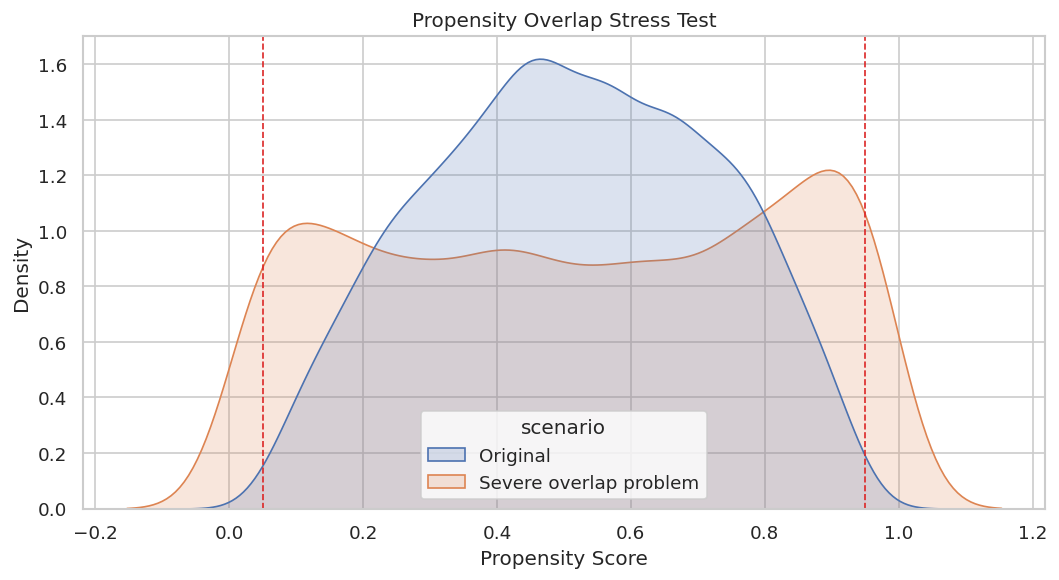

In [16]:
propensity_plot = pd.concat(
    [
        pd.DataFrame({"scenario": "Original", "propensity": data["true_propensity"]}),
        pd.DataFrame({"scenario": "Severe overlap problem", "propensity": overlap_demo["severe_propensity"]}),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=propensity_plot, x="propensity", hue="scenario", common_norm=False, fill=True, alpha=0.20, ax=ax)
ax.axvline(0.05, color="#dc2626", linestyle="--", linewidth=1)
ax.axvline(0.95, color="#dc2626", linestyle="--", linewidth=1)
ax.set_title("Propensity Overlap Stress Test")
ax.set_xlabel("Propensity Score")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_overlap_stress_test.png", dpi=160, bbox_inches="tight")
plt.show()


The severe scenario has much more density near the edges. A credible report would either restrict the target population, trim poor-overlap rows, or clearly state that estimates are weak in those regions.



#### Effective Sample Size Under Weighting

Inverse-propensity weights expose overlap problems numerically. When weights are highly concentrated, the effective sample size becomes much smaller than the raw row count.

In [17]:
# Define reusable helpers for the Effective Sample Size Under Weighting section.
def effective_sample_size(weights):
    """
    Idea: Summarize how concentrated a set of weights is by converting it to an effective sample size.
    
    Parameters
    ----------
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Effective sample size implied by the concentration of the weights.
    """
    weights = np.asarray(weights)
    return (weights.sum() ** 2) / np.sum(weights ** 2)

weight_rows = []
for scenario, treatment_col, propensity_col in [
    ("original", "treatment", "true_propensity"),
    ("severe_overlap_problem", "severe_treatment", "severe_propensity"),
]:
    treatment = overlap_demo[treatment_col].to_numpy() if treatment_col in overlap_demo else data[treatment_col].to_numpy()
    propensity = overlap_demo[propensity_col].to_numpy() if propensity_col in overlap_demo else data[propensity_col].to_numpy()
    weights = np.where(treatment == 1, 1 / propensity, 1 / (1 - propensity))
    weight_rows.append(
        {
            "scenario": scenario,
            "rows": len(weights),
            "effective_sample_size": effective_sample_size(weights),
            "max_weight": weights.max(),
            "p99_weight": np.quantile(weights, 0.99),
            "share_weights_above_10": np.mean(weights > 10),
        }
    )
weight_diagnostics = pd.DataFrame(weight_rows)
weight_diagnostics.to_csv(TABLE_DIR / f"{CASE_PREFIX}_weight_effective_sample_size.csv", index=False)
display(weight_diagnostics)


,scenario,rows,effective_sample_size,max_weight,p99_weight,share_weights_above_10
0,original,5200,"3,915.0554",20.0000,6.9137,0.0023
1,severe_overlap_problem,5200,"1,796.8555",77.9349,13.0630,0.0144


A large raw dataset can behave like a much smaller dataset when overlap is weak. This is a useful reality check before trusting granular CATE estimates.



#### Pitfall 2: Outcome Leakage

Outcome leakage occurs when a feature contains future outcome information or is built using data unavailable at treatment decision time. The next example adds `leaky_outcome_proxy` to the effect-modifier set.

This is intentionally wrong. The goal is to show that a model can look strong in a benchmark while being invalid for real deployment.

In [18]:
# Fit or evaluate the model objects used in the Pitfall 2: Outcome Leakage section.
LEAKY_X_COLUMNS = CLEAN_X_COLUMNS + ["leaky_outcome_proxy"]
X_train_leaky, W_train_leaky, T_train_leaky, Y_train_leaky, X_test_leaky, W_test_leaky, T_test_leaky, Y_test_leaky = build_design(
    train_df,
    test_df,
    LEAKY_X_COLUMNS,
    CLEAN_W_COLUMNS,
)

leaky_estimator = CausalForestDML(
    model_y=make_rf_regressor(301),
    model_t=make_rf_classifier(302),
    discrete_treatment=True,
    n_estimators=128,
    min_samples_leaf=18,
    max_samples=0.45,
    cv=3,
    random_state=RANDOM_STATE + 10,
)
start = time.perf_counter()
leaky_estimator.fit(Y_train_leaky, T_train_leaky, X=X_train_leaky, W=W_train_leaky)
leaky_fit_seconds = time.perf_counter() - start
leaky_effect = leaky_estimator.effect(X_test_leaky)

leaky_metrics = pd.DataFrame(
    [
        summarize_effects("Leaky CausalForestDML", leaky_effect, true_tau_test, leaky_fit_seconds, "Invalid: includes outcome-like future proxy."),
        summarize_effects(best_reference_label, best_reference_effect, true_tau_test, reference_metrics.iloc[0]["fit_seconds"], "Clean reference."),
    ]
).sort_values("cate_rmse")
leaky_metrics.to_csv(TABLE_DIR / f"{CASE_PREFIX}_leakage_metric_comparison.csv", index=False)
display(leaky_metrics)


,analysis,estimated_ate,true_ate_test,ate_bias,cate_rmse,cate_mae,cate_correlation,top_20_true_cate_mean,share_estimated_above_cost,true_net_policy_value,fit_seconds,notes
1,Clean DRLearner,0.3458,0.3723,-0.0266,0.2532,0.1999,0.8484,0.9207,0.6365,0.2813,3.3500,Clean reference.
0,Leaky CausalForestDML,0.0139,0.3723,-0.3584,0.5619,0.4536,0.4902,0.7223,0.0173,0.0190,2.9801,Invalid: includes outcome-like future proxy.


The leaky workflow may look competitive or even attractive by some metrics, but it is invalid because the feature would not be available at decision time. Good metrics cannot rescue a bad feature timeline.



#### Leakage Timing Check

A simple timing table often catches leakage faster than model diagnostics. Every feature should be available before treatment assignment if it is used for CATE estimation or targeting.

In [19]:
leakage_timing_check = pd.DataFrame(
    {
        "feature": LEAKY_X_COLUMNS + CLEAN_W_COLUMNS,
        "used_in_leaky_model": True,
    }
).merge(field_dictionary[["field", "timing", "modeling_status"]], left_on="feature", right_on="field", how="left")
leakage_timing_check["timing_flag"] = np.where(
    leakage_timing_check["timing"].eq("Pre-treatment"),
    "Allowed timing",
    "Invalid timing for decision-time modeling",
)
leakage_timing_check = leakage_timing_check.drop(columns=["field"])
leakage_timing_check.to_csv(TABLE_DIR / f"{CASE_PREFIX}_leakage_timing_check.csv", index=False)
display(leakage_timing_check.sort_values("timing_flag"))


,feature,used_in_leaky_model,timing,modeling_status,timing_flag
0,need_score,True,Pre-treatment,Allowed X.,Allowed timing
1,prior_activity,True,Pre-treatment,Allowed X.,Allowed timing
2,preference_match,True,Pre-treatment,Allowed X.,Allowed timing
3,search_friction,True,Pre-treatment,Allowed X.,Allowed timing
4,price_sensitivity,True,Pre-treatment,Allowed X.,Allowed timing
5,device_quality,True,Pre-treatment,Allowed X.,Allowed timing
6,high_intent_segment,True,Pre-treatment,Allowed X.,Allowed timing
8,marketing_intensity,True,Pre-treatment,Allowed W.,Allowed timing
9,competitive_pressure,True,Pre-treatment,Allowed W.,Allowed timing
10,market_maturity,True,Pre-treatment,Allowed W.,Allowed timing


The timing flag is the right conclusion, regardless of the metric table. Leakage is a design error, not a hyperparameter problem.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->




#### Pitfall 3: Bad Nuisance Models

DML depends on nuisance models for treatment and outcome. If those nuisance models are too weak, the final treatment-effect estimates can be biased or poorly ranked.

The next cell compares the clean flexible reference with a deliberately simple `LinearDML` setup.

In [20]:
bad_nuisance_estimator = LinearDML(
    model_y=LinearRegression(),
    model_t=LogisticRegression(max_iter=1_000),
    discrete_treatment=True,
    cv=3,
    random_state=RANDOM_STATE + 20,
)
start = time.perf_counter()
bad_nuisance_estimator.fit(Y_train, T_train, X=X_train, W=W_train)
bad_nuisance_fit_seconds = time.perf_counter() - start
bad_nuisance_effect = bad_nuisance_estimator.effect(X_test)

bad_nuisance_metrics = pd.DataFrame(
    [
        summarize_effects("Too-simple LinearDML", bad_nuisance_effect, true_tau_test, bad_nuisance_fit_seconds, "Uses weak linear nuisance models."),
        summarize_effects(best_reference_label, best_reference_effect, true_tau_test, reference_metrics.iloc[0]["fit_seconds"], "Clean flexible reference."),
    ]
).sort_values("cate_rmse")
bad_nuisance_metrics.to_csv(TABLE_DIR / f"{CASE_PREFIX}_bad_nuisance_comparison.csv", index=False)
display(bad_nuisance_metrics)


,analysis,estimated_ate,true_ate_test,ate_bias,cate_rmse,cate_mae,cate_correlation,top_20_true_cate_mean,share_estimated_above_cost,true_net_policy_value,fit_seconds,notes
0,Too-simple LinearDML,0.3504,0.3723,-0.0219,0.1685,0.1326,0.9280,0.9762,0.6827,0.2914,0.0388,Uses weak linear nuisance models.
1,Clean DRLearner,0.3458,0.3723,-0.0266,0.2532,0.1999,0.8484,0.9207,0.6365,0.2813,3.3500,Clean flexible reference.


The simple nuisance setup serves a different role than automatically wrong. It is risky when the true data-generating process is nonlinear. Nuisance diagnostics help reveal whether that risk is material.



#### Nuisance Diagnostic Comparison

Here we compare simple and flexible nuisance models directly on the held-out sample. The check catches obviously weak adjustment machinery while leaving final CATE validity to the full design.

In [21]:
# Fit or evaluate the model objects used in the Nuisance Diagnostic Comparison section.
XW_train = pd.concat([X_train, W_train], axis=1)
XW_test = pd.concat([X_test, W_test], axis=1)

simple_propensity = LogisticRegression(max_iter=1_000)
simple_propensity.fit(XW_train, T_train)
simple_propensity_pred = np.clip(simple_propensity.predict_proba(XW_test)[:, 1], 1e-4, 1 - 1e-4)

flex_propensity = make_rf_classifier(401)
flex_propensity.fit(XW_train, T_train)
flex_propensity_pred = np.clip(flex_propensity.predict_proba(XW_test)[:, 1], 1e-4, 1 - 1e-4)

simple_outcome = LinearRegression()
simple_outcome.fit(pd.concat([XW_train, T_train.rename("treatment")], axis=1), Y_train)
simple_outcome_pred = simple_outcome.predict(pd.concat([XW_test, T_test.rename("treatment")], axis=1))

flex_outcome = make_rf_regressor(402)
flex_outcome.fit(pd.concat([XW_train, T_train.rename("treatment")], axis=1), Y_train)
flex_outcome_pred = flex_outcome.predict(pd.concat([XW_test, T_test.rename("treatment")], axis=1))

nuisance_comparison = pd.DataFrame(
    [
        {
            "model": "simple_propensity_logistic",
            "task": "treatment",
            "auc": roc_auc_score(T_test, simple_propensity_pred),
            "log_loss": log_loss(T_test, simple_propensity_pred),
            "r2": np.nan,
            "mae": np.nan,
        },
        {
            "model": "flex_propensity_forest",
            "task": "treatment",
            "auc": roc_auc_score(T_test, flex_propensity_pred),
            "log_loss": log_loss(T_test, flex_propensity_pred),
            "r2": np.nan,
            "mae": np.nan,
        },
        {
            "model": "simple_outcome_linear",
            "task": "outcome",
            "auc": np.nan,
            "log_loss": np.nan,
            "r2": r2_score(Y_test, simple_outcome_pred),
            "mae": mean_absolute_error(Y_test, simple_outcome_pred),
        },
        {
            "model": "flex_outcome_forest",
            "task": "outcome",
            "auc": np.nan,
            "log_loss": np.nan,
            "r2": r2_score(Y_test, flex_outcome_pred),
            "mae": mean_absolute_error(Y_test, flex_outcome_pred),
        },
    ]
)
nuisance_comparison.to_csv(TABLE_DIR / f"{CASE_PREFIX}_nuisance_model_comparison.csv", index=False)
display(nuisance_comparison)


,model,task,auc,log_loss,r2,mae
0,simple_propensity_logistic,treatment,0.7623,0.5815,NaN,NaN
1,flex_propensity_forest,treatment,0.7395,0.6020,NaN,NaN
2,simple_outcome_linear,outcome,NaN,NaN,0.5922,0.6025
3,flex_outcome_forest,outcome,NaN,NaN,0.5381,0.6366


When nuisance models perform poorly, treatment-effect estimates deserve extra caution. The CATE model is not separate from the quality of the adjustment stage.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




#### Pitfall 4: Post-Treatment Controls

A post-treatment variable can be a mediator: treatment changes it, and it partly carries the treatment effect to the outcome. If we adjust for it as if it were a confounder, we may estimate a different effect than intended.

The next cell adds `post_treatment_activity` to `W`, which is intentionally wrong for the total effect estimand.

In [22]:
# Fit or evaluate the model objects used in the Pitfall 4: Post-Treatment Controls section.
POST_CONTROL_W_COLUMNS = CLEAN_W_COLUMNS + ["post_treatment_activity"]
X_train_post, W_train_post, T_train_post, Y_train_post, X_test_post, W_test_post, T_test_post, Y_test_post = build_design(
    train_df,
    test_df,
    CLEAN_X_COLUMNS,
    POST_CONTROL_W_COLUMNS,
)

post_control_estimator = CausalForestDML(
    model_y=make_rf_regressor(501),
    model_t=make_rf_classifier(502),
    discrete_treatment=True,
    n_estimators=128,
    min_samples_leaf=18,
    max_samples=0.45,
    cv=3,
    random_state=RANDOM_STATE + 30,
)
start = time.perf_counter()
post_control_estimator.fit(Y_train_post, T_train_post, X=X_train_post, W=W_train_post)
post_control_fit_seconds = time.perf_counter() - start
post_control_effect = post_control_estimator.effect(X_test_post)

post_control_metrics = pd.DataFrame(
    [
        summarize_effects("Post-treatment control CausalForestDML", post_control_effect, true_tau_test, post_control_fit_seconds, "Invalid for total effect: controls for mediator-like field."),
        summarize_effects(best_reference_label, best_reference_effect, true_tau_test, reference_metrics.iloc[0]["fit_seconds"], "Clean total-effect reference."),
    ]
).sort_values("estimated_ate")
post_control_metrics.to_csv(TABLE_DIR / f"{CASE_PREFIX}_post_treatment_control_comparison.csv", index=False)
display(post_control_metrics)


,analysis,estimated_ate,true_ate_test,ate_bias,cate_rmse,cate_mae,cate_correlation,top_20_true_cate_mean,share_estimated_above_cost,true_net_policy_value,fit_seconds,notes
0,Post-treatment control CausalForestDML,0.3218,0.3723,-0.0505,0.2666,0.2087,0.8733,0.9476,0.7115,0.2805,3.2100,Invalid for total effect: controls for mediator-like field.
1,Clean DRLearner,0.3458,0.3723,-0.0266,0.2532,0.1999,0.8484,0.9207,0.6365,0.2813,3.3500,Clean total-effect reference.


Adding a post-treatment control changes the question being answered. If the target is the total effect of treatment, downstream variables should not be adjusted away as ordinary confounders.



#### Post-Treatment Field Timing Check

The code below makes the timing violation explicit. A good review process should catch this before the estimator is ever run.

In [23]:
post_control_timing = pd.DataFrame({"feature": CLEAN_X_COLUMNS + POST_CONTROL_W_COLUMNS}).merge(
    field_dictionary[["field", "timing", "modeling_status"]],
    left_on="feature",
    right_on="field",
    how="left",
).drop(columns=["field"])
post_control_timing["timing_flag"] = np.where(
    post_control_timing["timing"].eq("Pre-treatment"),
    "Allowed timing",
    "Invalid for total-effect adjustment",
)
post_control_timing.to_csv(TABLE_DIR / f"{CASE_PREFIX}_post_treatment_timing_check.csv", index=False)
display(post_control_timing.sort_values("timing_flag"))


,feature,timing,modeling_status,timing_flag
0,need_score,Pre-treatment,Allowed X.,Allowed timing
1,prior_activity,Pre-treatment,Allowed X.,Allowed timing
2,preference_match,Pre-treatment,Allowed X.,Allowed timing
3,search_friction,Pre-treatment,Allowed X.,Allowed timing
4,price_sensitivity,Pre-treatment,Allowed X.,Allowed timing
5,device_quality,Pre-treatment,Allowed X.,Allowed timing
6,high_intent_segment,Pre-treatment,Allowed X.,Allowed timing
7,marketing_intensity,Pre-treatment,Allowed W.,Allowed timing
8,competitive_pressure,Pre-treatment,Allowed W.,Allowed timing
9,market_maturity,Pre-treatment,Allowed W.,Allowed timing


The timing table is more important than whether the post-control model seems accurate. Causal validity is primarily a design issue.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->




#### Pitfall 5: Overreading Unit-Level CATE

CATE predictions can rank users reasonably while remaining noisy at the individual level. Decile calibration is a healthier way to discuss heterogeneity than treating every user's estimate as exact.

In [24]:
calibration_parts = []
comparison_effects = {
    best_reference_label: best_reference_effect,
    "Too-simple LinearDML": bad_nuisance_effect,
    "Leaky CausalForestDML": leaky_effect,
    "Post-treatment control": post_control_effect,
}
for label, estimated in comparison_effects.items():
    temp = pd.DataFrame({"user_id": test_df["user_id"], "true_cate": true_tau_test, "estimated_cate": estimated})
    temp["estimated_decile"] = pd.qcut(temp["estimated_cate"], q=10, labels=False, duplicates="drop") + 1
    summary = (
        temp.groupby("estimated_decile", observed=True)
        .agg(users=("user_id", "size"), mean_estimated_cate=("estimated_cate", "mean"), mean_true_cate=("true_cate", "mean"))
        .reset_index()
    )
    summary["analysis"] = label
    calibration_parts.append(summary)

calibration_table = pd.concat(calibration_parts, ignore_index=True)
calibration_table.to_csv(TABLE_DIR / f"{CASE_PREFIX}_decile_calibration_comparison.csv", index=False)
display(calibration_table.head(15))


,estimated_decile,users,mean_estimated_cate,mean_true_cate,analysis
0,1,156,-0.3712,-0.2142,Clean DRLearner
1,2,156,-0.1326,-0.0505,Clean DRLearner
2,3,156,0.0006,0.0596,Clean DRLearner
3,4,156,0.1402,0.1905,Clean DRLearner
4,5,156,0.2685,0.3146,Clean DRLearner
5,6,156,0.3848,0.4333,Clean DRLearner
6,7,156,0.4985,0.5173,Clean DRLearner
7,8,156,0.6140,0.6313,Clean DRLearner
8,9,156,0.7944,0.7605,Clean DRLearner
9,10,156,1.2603,1.0810,Clean DRLearner


A useful CATE model should show higher true effects in higher estimated deciles. If that pattern is weak or inconsistent, the model should not drive precise individual-level claims.



#### Decile Calibration Plot

The plot shows whether estimated deciles correspond to real effect differences. This is a better communication device than a long list of user-level predictions.

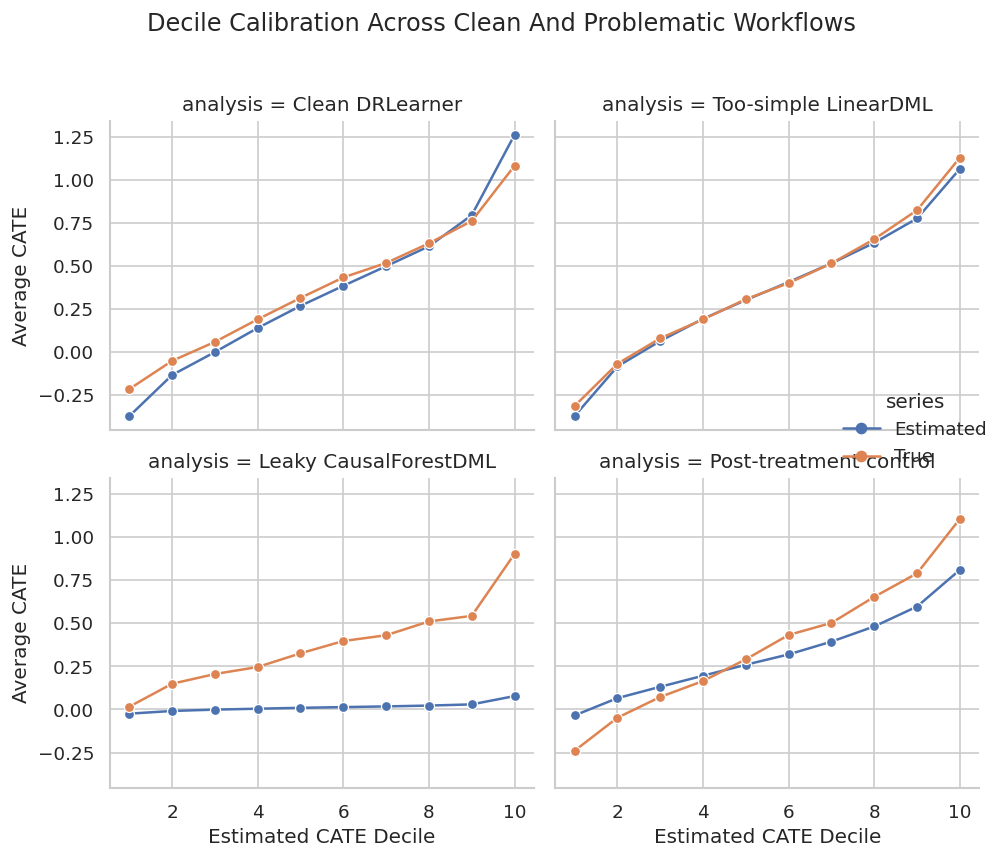

In [25]:
calibration_plot = calibration_table.melt(
    id_vars=["analysis", "estimated_decile", "users"],
    value_vars=["mean_estimated_cate", "mean_true_cate"],
    var_name="series",
    value_name="cate",
)
calibration_plot["series"] = calibration_plot["series"].map({"mean_estimated_cate": "Estimated", "mean_true_cate": "True"})

g = sns.relplot(
    data=calibration_plot,
    x="estimated_decile",
    y="cate",
    hue="series",
    col="analysis",
    col_wrap=2,
    kind="line",
    marker="o",
    height=3.5,
    facet_kws={"sharey": True},
)
g.set_axis_labels("Estimated CATE Decile", "Average CATE")
g.fig.suptitle("Decile Calibration Across Clean And Problematic Workflows", y=1.02)
plt.tight_layout()
g.fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_decile_calibration_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


Calibration plots make overclaiming harder. A model may still be useful for coarse targeting even when individual-level predictions are noisy.

The decision implication is that estimated gains need to be filtered through uncertainty, cost, support, and operational constraints before becoming actions.
<!-- result-implication-expanded -->




#### Pitfall 6: Segment Hunting

If analysts search enough segments, some will appear unusually high or low by chance. The next cell creates random segments unrelated to the causal design and measures how extreme their apparent true effects can look.

In [26]:
segment_rng = np.random.default_rng(RANDOM_STATE + 77)
random_segment_rows = []
for segment_id in range(1, 81):
    segment_share = segment_rng.uniform(0.08, 0.35)
    segment_mask = segment_rng.random(len(test_df)) < segment_share
    if segment_mask.sum() < 30:
        continue
    random_segment_rows.append(
        {
            "segment": f"random_segment_{segment_id:02d}",
            "users": int(segment_mask.sum()),
            "mean_true_cate": true_tau_test[segment_mask].mean(),
            "mean_reference_cate": best_reference_effect[segment_mask].mean(),
            "reference_minus_true": best_reference_effect[segment_mask].mean() - true_tau_test[segment_mask].mean(),
        }
    )
random_segment_scan = pd.DataFrame(random_segment_rows).sort_values("mean_reference_cate", ascending=False)
random_segment_scan.to_csv(TABLE_DIR / f"{CASE_PREFIX}_random_segment_scan.csv", index=False)
display(random_segment_scan.head(10))


,segment,users,mean_true_cate,mean_reference_cate,reference_minus_true
36,random_segment_37,123,0.4217,0.4118,-0.0099
4,random_segment_05,119,0.4246,0.4007,-0.0239
52,random_segment_53,252,0.4292,0.4000,-0.0292
33,random_segment_34,178,0.4011,0.3921,-0.0090
59,random_segment_60,527,0.4138,0.3881,-0.0258
72,random_segment_73,325,0.4011,0.3815,-0.0196
37,random_segment_38,467,0.3948,0.3799,-0.0149
19,random_segment_20,322,0.4001,0.3794,-0.0207
0,random_segment_01,259,0.3844,0.3778,-0.0066
57,random_segment_58,309,0.3835,0.3732,-0.0104


Some random segments can look impressive simply because many were searched. Segment results should be pre-specified when possible, and exploratory segments should be labeled as exploratory.



#### Random Segment Distribution

The distribution of random segment means shows how much apparent heterogeneity can appear even when the segments are arbitrary.

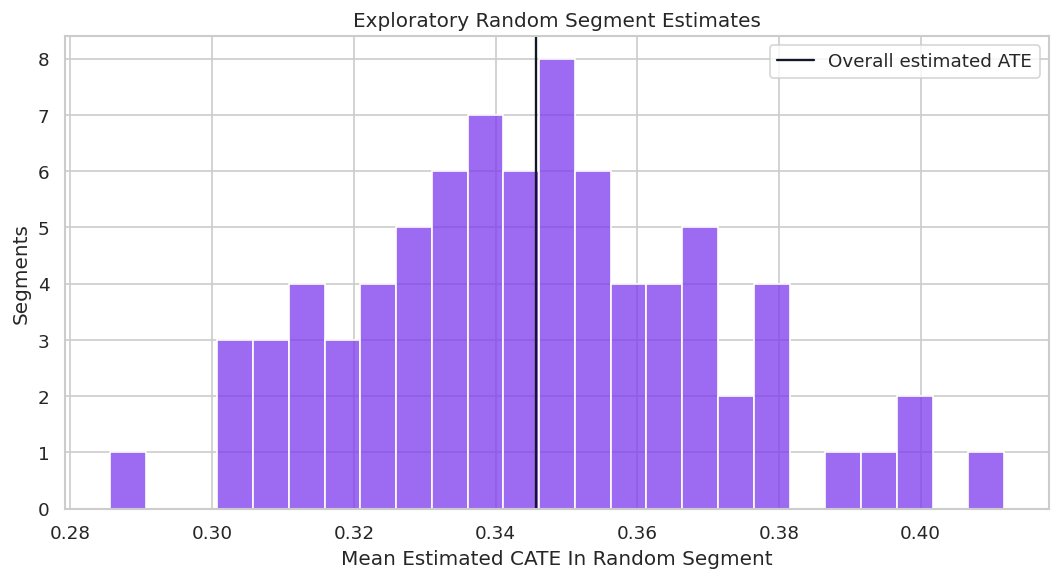

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(random_segment_scan["mean_reference_cate"], bins=25, color="#7c3aed", alpha=0.75, ax=ax)
ax.axvline(best_reference_effect.mean(), color="#111827", linewidth=1.4, label="Overall estimated ATE")
ax.set_title("Exploratory Random Segment Estimates")
ax.set_xlabel("Mean Estimated CATE In Random Segment")
ax.set_ylabel("Segments")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_random_segment_hunting.png", dpi=160, bbox_inches="tight")
plt.show()

This plot is a warning against cherry-picked segment stories. A credible report should distinguish planned segments from exploratory discoveries.

The figure matters because it turns the numeric output into a pattern that can be inspected before trusting the next modeling step.
<!-- result-implication-expanded -->


#### Policy Value Comparison Across Workflows

The next table translates each workflow into a simple rule: treat users with estimated CATE above cost. This reveals how design mistakes affect decisions, more than model metrics.

In [28]:
# Save the artifacts produced by the Policy Value Comparison Across Workflows section.
policy_rows = []
for label, estimated in comparison_effects.items():
    action = estimated > TREATMENT_COST
    policy_rows.append(
        {
            "analysis": label,
            "treatment_rate": action.mean(),
            "users_treated": int(action.sum()),
            "mean_true_cate_among_treated": true_tau_test[action].mean() if action.sum() else np.nan,
            "precision_positive_net": np.mean(true_tau_test[action] > TREATMENT_COST) if action.sum() else np.nan,
            "true_net_value_per_user": ((true_tau_test - TREATMENT_COST) * action).mean(),
        }
    )
policy_rows.extend(
    [
        {
            "analysis": "Treat none",
            "treatment_rate": 0.0,
            "users_treated": 0,
            "mean_true_cate_among_treated": np.nan,
            "precision_positive_net": np.nan,
            "true_net_value_per_user": 0.0,
        },
        {
            "analysis": "Treat all",
            "treatment_rate": 1.0,
            "users_treated": len(test_df),
            "mean_true_cate_among_treated": true_tau_test.mean(),
            "precision_positive_net": np.mean(true_tau_test > TREATMENT_COST),
            "true_net_value_per_user": (true_tau_test - TREATMENT_COST).mean(),
        },
    ]
)
policy_comparison = pd.DataFrame(policy_rows).sort_values("true_net_value_per_user", ascending=False)
policy_comparison.to_csv(TABLE_DIR / f"{CASE_PREFIX}_policy_value_comparison.csv", index=False)
display(policy_comparison)


,analysis,treatment_rate,users_treated,mean_true_cate_among_treated,precision_positive_net,true_net_value_per_user
1,Too-simple LinearDML,0.6827,1065,0.5868,0.9070,0.2914
0,Clean DRLearner,0.6365,993,0.6018,0.9033,0.2813
3,Post-treatment control,0.7115,1110,0.5542,0.8613,0.2805
5,Treat all,1.0000,1560,0.3723,0.6679,0.2123
2,Leaky CausalForestDML,0.0173,27,1.2598,1.0000,0.0190
4,Treat none,0.0000,0,NaN,NaN,0.0000


Policy value is the practical consequence of modeling choices. Invalid designs should still be rejected even if their policy table looks good in this simulated benchmark.



#### Policy Value Plot

This plot compares net value per held-out user across clean and problematic workflows. The invalid analyses are included to show why the diagnostics matter.

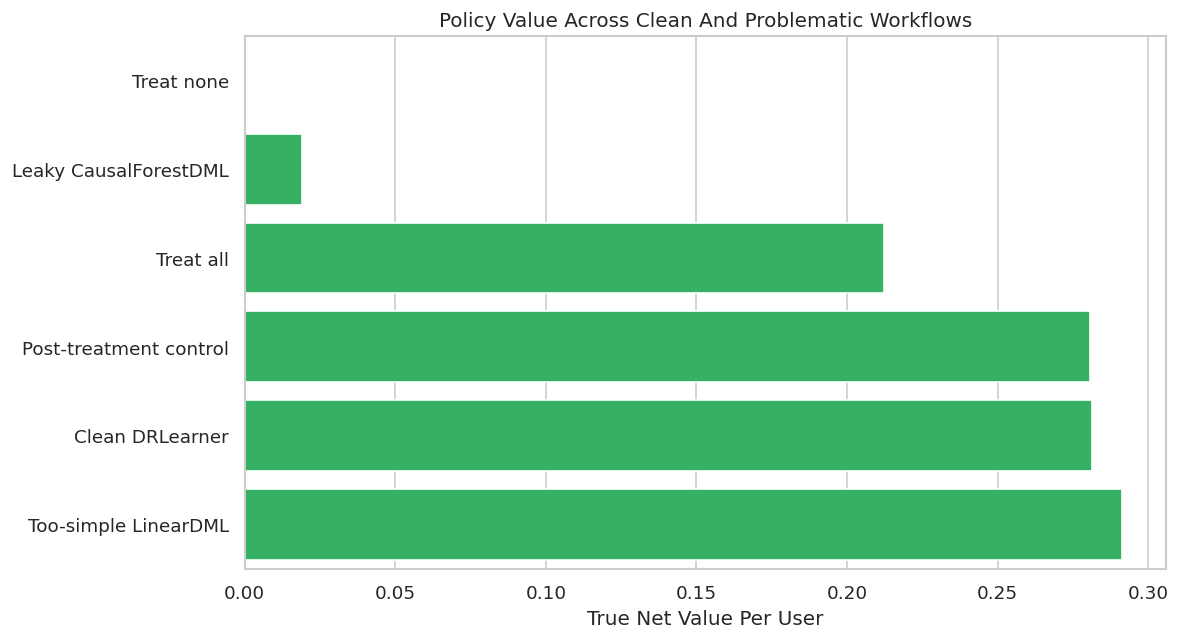

In [29]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_policy = policy_comparison.sort_values("true_net_value_per_user")
sns.barplot(data=plot_policy, x="true_net_value_per_user", y="analysis", color="#22c55e", ax=ax)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Policy Value Across Clean And Problematic Workflows")
ax.set_xlabel("True Net Value Per User")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_policy_value_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The chart is useful only when read together with validity checks. A design can generate value in a teaching simulation and still be unusable in real deployment because it relies on future information or changes the estimand.



#### Bootstrap Policy Uncertainty

A single held-out value can be noisy. Bootstrapping held-out rows shows how much policy value changes across plausible evaluation samples.

In [30]:
# Save the artifacts produced by the Bootstrap Policy Uncertainty section.
bootstrap_rng = np.random.default_rng(RANDOM_STATE + 123)
N_BOOTSTRAPS = 300
policy_actions = {label: (estimated > TREATMENT_COST) for label, estimated in comparison_effects.items()}
policy_actions["Treat none"] = np.zeros(len(test_df), dtype=bool)
policy_actions["Treat all"] = np.ones(len(test_df), dtype=bool)

bootstrap_rows = []
for draw in range(N_BOOTSTRAPS):
    sample_index = bootstrap_rng.choice(len(test_df), size=len(test_df), replace=True)
    for label, action in policy_actions.items():
        value = ((true_tau_test[sample_index] - TREATMENT_COST) * action[sample_index]).mean()
        bootstrap_rows.append({"draw": draw, "analysis": label, "true_net_value_per_user": value})
bootstrap_policy = pd.DataFrame(bootstrap_rows)
bootstrap_policy_summary = (
    bootstrap_policy.groupby("analysis")
    .agg(
        mean_value=("true_net_value_per_user", "mean"),
        lower_95=("true_net_value_per_user", lambda values: np.quantile(values, 0.025)),
        upper_95=("true_net_value_per_user", lambda values: np.quantile(values, 0.975)),
    )
    .reset_index()
    .sort_values("mean_value", ascending=False)
)
bootstrap_policy.to_csv(TABLE_DIR / f"{CASE_PREFIX}_bootstrap_policy_values.csv", index=False)
bootstrap_policy_summary.to_csv(TABLE_DIR / f"{CASE_PREFIX}_bootstrap_policy_summary.csv", index=False)
display(bootstrap_policy_summary)


,analysis,mean_value,lower_95,upper_95
3,Too-simple LinearDML,0.2916,0.2747,0.3080
0,Clean DRLearner,0.2816,0.2653,0.2972
2,Post-treatment control,0.2807,0.2641,0.2977
4,Treat all,0.2126,0.1903,0.2342
1,Leaky CausalForestDML,0.0193,0.0122,0.0266
5,Treat none,0.0000,0.0000,0.0000


Bootstrap intervals help avoid false precision. If two valid policies overlap heavily, the report should not oversell their ordering.

For causal interpretation, this is a support check: weak overlap can make an estimator depend on extrapolation instead of comparable treated and control units.
<!-- result-implication-expanded -->


#### Bootstrap Policy Interval Plot

The interval plot summarizes the uncertainty around each policy's net value. Invalid workflows remain labeled as workflows, but they should not be recommended.

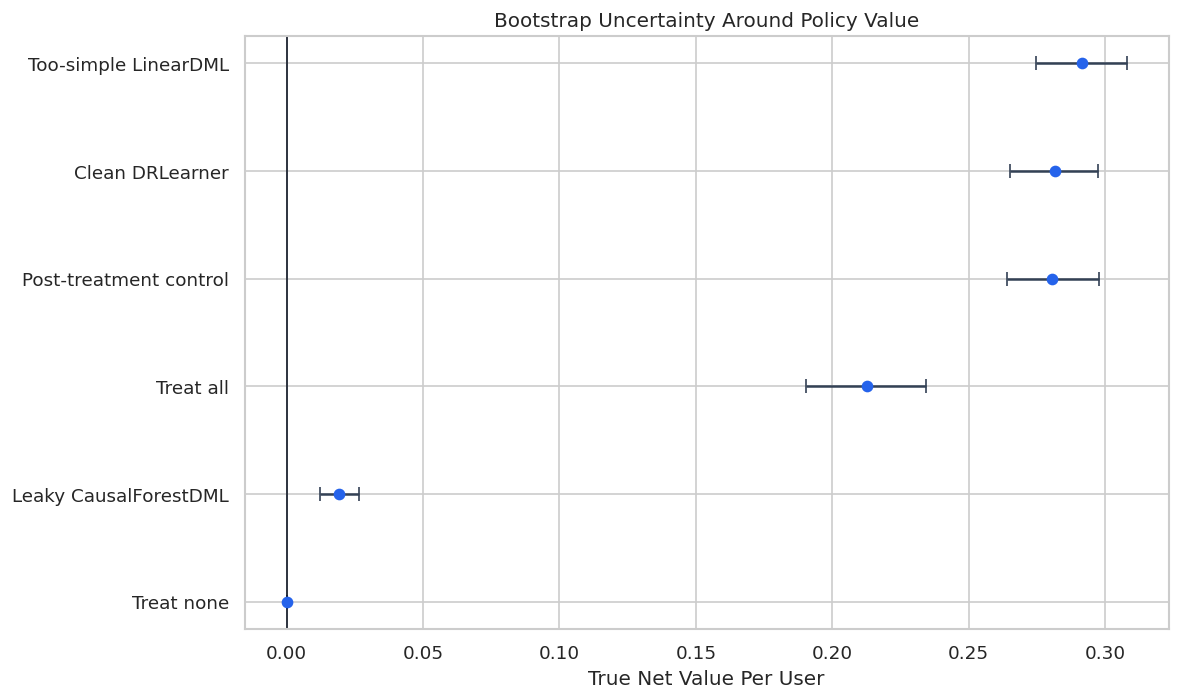

In [31]:
plot_bootstrap = bootstrap_policy_summary.sort_values("mean_value")
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(
    x=plot_bootstrap["mean_value"],
    y=plot_bootstrap["analysis"],
    xerr=[
        plot_bootstrap["mean_value"] - plot_bootstrap["lower_95"],
        plot_bootstrap["upper_95"] - plot_bootstrap["mean_value"],
    ],
    fmt="o",
    color="#2563eb",
    ecolor="#334155",
    capsize=4,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Bootstrap Uncertainty Around Policy Value")
ax.set_xlabel("True Net Value Per User")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{CASE_PREFIX}_bootstrap_policy_intervals.png", dpi=160, bbox_inches="tight")
plt.show()


The interval view encourages a more measured conclusion. It also makes clear why model comparison should include uncertainty, more than rank ordering.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


#### Consolidated Failure Mode Scorecard

This scorecard collects the major examples in one place. The key column is not the metric value alone; it is whether the workflow is valid for the intended total-effect decision.

In [32]:
# Save the artifacts produced by the Consolidated Failure Mode Scorecard section.
all_metric_rows = pd.concat(
    [
        reference_metrics,
        leaky_metrics[leaky_metrics["analysis"].eq("Leaky CausalForestDML")],
        bad_nuisance_metrics[bad_nuisance_metrics["analysis"].eq("Too-simple LinearDML")],
        post_control_metrics[post_control_metrics["analysis"].eq("Post-treatment control CausalForestDML")],
    ],
    ignore_index=True,
)
validity_map = {
    "Clean CausalForestDML": "Valid design, subject to unconfoundedness and overlap.",
    "Clean DRLearner": "Valid design, subject to unconfoundedness and overlap.",
    "Leaky CausalForestDML": "Invalid: uses outcome-like future information.",
    "Too-simple LinearDML": "Valid timing, but high model-risk if nuisance models are misspecified.",
    "Post-treatment control CausalForestDML": "Invalid for total effect: adjusts for downstream variable.",
}
scorecard = all_metric_rows[[
    "analysis",
    "estimated_ate",
    "ate_bias",
    "cate_rmse",
    "cate_correlation",
    "true_net_policy_value",
    "fit_seconds",
]].copy()
scorecard["validity_assessment"] = scorecard["analysis"].map(validity_map)
scorecard = scorecard.sort_values("true_net_policy_value", ascending=False)
scorecard.to_csv(TABLE_DIR / f"{CASE_PREFIX}_failure_mode_scorecard.csv", index=False)
display(scorecard)


,analysis,estimated_ate,ate_bias,cate_rmse,cate_correlation,true_net_policy_value,fit_seconds,validity_assessment
3,Too-simple LinearDML,0.3504,-0.0219,0.1685,0.9280,0.2914,0.0388,"Valid timing, but high model-risk if nuisance models are misspecified."
1,Clean CausalForestDML,0.3609,-0.0115,0.2667,0.8733,0.2815,3.1151,"Valid design, subject to unconfoundedness and overlap."
0,Clean DRLearner,0.3458,-0.0266,0.2532,0.8484,0.2813,3.3500,"Valid design, subject to unconfoundedness and overlap."
4,Post-treatment control CausalForestDML,0.3218,-0.0505,0.2666,0.8733,0.2805,3.2100,Invalid for total effect: adjusts for downstream variable.
2,Leaky CausalForestDML,0.0139,-0.3584,0.5619,0.4902,0.0190,2.9801,Invalid: uses outcome-like future information.


The scorecard demonstrates a central reporting habit: separate performance from validity. Invalid workflows should not become recommendations just because they score well.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->




#### Debugging Playbook

The playbook turns the notebook examples into a sequence of questions to ask whenever an EconML result looks surprising.

| symptom | first_debugging_moves |
| --- | --- |
| Effect estimate is much larger than expected | Check leakage, post-treatment controls, target population mismatch, and raw treated-control imbalance. |
| CATE estimates look extremely spread out | Check overlap, nuisance model instability, small leaves, and whether X includes noisy identifiers. |
| Policy treats almost everyone | Compare estimated CATE distribution to cost and inspect propensity support among treated recommendations. |
| Top segment looks too good | Confirm the segment was pre-specified and compare against random segment scans. |
| Estimator rankings disagree | Compare nuisance diagnostics, calibration, segment behavior, and bootstrap intervals rather than choosing by one metric. |
| Confidence seems too high | Check sample size, overlap, repeated model selection, and whether uncertainty includes policy-selection uncertainty. |
| A feature is very predictive | Audit whether it exists before treatment and whether it is a mediator, collider, or outcome proxy. |


The playbook is intentionally practical. Most debugging starts with a suspicious result and then works backward through timing, overlap, model quality, and decision logic.



#### Reporting Checklist

A transparent causal report should make assumptions and diagnostics visible. The checklist below is designed for EconML analyses, but the same structure works for most observational causal projects.

| report_section | what_to_include |
| --- | --- |
| Causal question | Treatment, outcome, target population, and estimand are written plainly. |
| Feature timing | Every model feature is confirmed to be pre-treatment for the target decision. |
| Confounder logic | The report explains why included controls are plausible confounders and what may be missing. |
| Overlap | Propensity distributions, bucket counts, or support filters are shown. |
| Nuisance models | Treatment and outcome nuisance diagnostics are reported. |
| Estimator comparison | Results are checked across at least one reasonable alternative estimator or specification. |
| Heterogeneity | CATE claims are summarized by calibrated groups or segments, more than individual scores. |
| Policy value | Treatment cost, threshold rule, treatment rate, and net value are reported. |
| Uncertainty | Intervals or bootstrap checks are included for key estimates or policy values. |
| Limitations | Unobserved confounding, overlap gaps, measurement limits, and validation needs are stated. |


The checklist makes the final result reviewable. A model output without these ingredients should be treated as a preliminary analysis, not a decision-ready causal estimate.

#### Short Report Template

The final code cell writes a compact markdown report template using the notebook's computed results. It emphasizes validity, more than performance.

In [33]:
# Prepare intermediate objects for the Short Report Template section.
best_valid_policy = policy_comparison[policy_comparison["analysis"].isin(list(reference_effects.keys()))].iloc[0]
best_valid_metric = reference_metrics.iloc[0]

report_lines = [
    "# EconML Debugging And Reporting Summary",
    "",
    "## Recommended Valid Workflow",
    "",
    f"The strongest valid reference workflow in this teaching run is **{best_valid_metric['analysis']}**.",
    "",
    f"- Held-out CATE RMSE: `{best_valid_metric['cate_rmse']:.4f}`",
    f"- Held-out CATE correlation: `{best_valid_metric['cate_correlation']:.4f}`",
    f"- Net policy value per user: `{best_valid_policy['true_net_value_per_user']:.4f}`",
    f"- Treatment rate under cost threshold: `{best_valid_policy['treatment_rate']:.1%}`",
    "",
    "## Main Lessons",
    "",
    "1. Strong-looking metrics do not fix invalid feature timing.",
    "2. Weak overlap reduces the effective information available for causal estimation.",
    "3. Bad nuisance models can distort both average and heterogeneous effects.",
    "4. Post-treatment controls can change the estimand by blocking part of the treatment pathway.",
    "5. CATE estimates should be reported with calibration, segment checks, policy value, and uncertainty.",
    "",
    "## Required Caveats",
    "",
    "We use synthetic data with known truth. In real observational analysis, the report must include domain justification for confounders, evidence of overlap, sensitivity to modeling choices, and validation plans before a policy recommendation is treated as decision-ready.",
]
report_text = "\n".join(report_lines)
report_path = REPORT_DIR / f"{CASE_PREFIX}_debugging_reporting_summary.md"
report_path.write_text(report_text)
display(Markdown(report_text))
print(f"Saved report to: {report_path}")


# EconML Debugging And Reporting Summary

## Recommended Valid Workflow

The strongest valid reference workflow in this teaching run is **Clean DRLearner**.

- Held-out CATE RMSE: `0.2532`
- Held-out CATE correlation: `0.8484`
- Net policy value per user: `0.2813`
- Treatment rate under cost threshold: `63.7%`

## Main Lessons

1. Strong-looking metrics do not fix invalid feature timing.
2. Weak overlap reduces the effective information available for causal estimation.
3. Bad nuisance models can distort both average and heterogeneous effects.
4. Post-treatment controls can change the estimand by blocking part of the treatment pathway.
5. CATE estimates should be reported with calibration, segment checks, policy value, and uncertainty.

## Required Caveats

We use synthetic data with known truth. In real observational analysis, the report must include domain justification for confounders, evidence of overlap, sensitivity to modeling choices, and validation plans before a policy recommendation is treated as decision-ready.

Saved report to: /home/apex/Documents/portfolio/notebooks/tutorials/econml/outputs/reports/15_debugging_reporting_summary.md


The report template closes the tutorial series on the right note. The strongest causal analysis is the one whose design, diagnostics, limitations, and decision logic are clear.

#### Final Takeaways

EconML is powerful when the causal question is well-defined and the analyst respects the assumptions. The recurring pattern across this tutorial sequence is simple: define the estimand, protect feature timing, diagnose overlap, check nuisance models, validate heterogeneity at group level, quantify policy value, and report limitations honestly.

That discipline is what turns treatment-effect modeling from an impressive notebook into credible applied causal work.